In [1]:
import psutil
import json
import os
import math
import gc
import random
import pathlib
import collections 
from typing import NamedTuple

os.environ['HF_HOME'] = '.hf'

import joblib
import tqdm.auto
import transformers
import torch
import plotly.express
import sklearn.decomposition
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
import safetensors
import safetensors.torch
import plotly.express
import plotly.graph_objects

from torch import Tensor



In [2]:
class ModelInfo(NamedTuple):
    tag: str
    name: str
    arange: torch.Tensor
    tokenizer: transformers.PreTrainedTokenizerFast | None
    ids: torch.Tensor | None
    embs: torch.Tensor
    display_name: str


def load_model(tag: str, model_name: str, arange: torch.Tensor, shuffle: bool, cache_file: pathlib.Path, display_name: str) -> ModelInfo:
    tokenizer: transformers.PreTrainedTokenizerFast = transformers.AutoTokenizer.from_pretrained(model_name)
    ids = [tokenizer.convert_tokens_to_ids(str(i)) for i in arange.tolist()]
    
    if cache_file.exists():
        with safetensors.safe_open(cache_file, framework="pt") as f:
            embs = f.get_tensor("embs")
    else:
        model: transformers.PreTrainedModel = transformers.AutoModel.from_pretrained(model_name).eval()
        embs = model.get_input_embeddings().weight[ids].detach().clone()
        del model
        gc.collect()
        safetensors.torch.save_file({"embs": embs}, cache_file)

    if shuffle:
        embs = embs[torch.randperm(len(embs), generator=torch.Generator().manual_seed(0))]
    
    return ModelInfo(tag=tag, name=model_name, arange=arange, tokenizer=tokenizer, ids=None, embs=embs, display_name=display_name)


def load_standard_gaussian(tag: str, model_name: str, arange: Tensor, display_name: str) -> ModelInfo:
    model_dim = transformers.AutoConfig.from_pretrained(model_name).hidden_size
    tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
    rng_gen = torch.Generator().manual_seed(0)
    shape = (arange.numel(), model_dim)
    embs = torch.normal(mean=torch.zeros(shape), std=torch.ones(shape), generator=rng_gen)
    return ModelInfo(tag=tag, name=model_name, arange=arange, tokenizer=tokenizer, ids=None, embs=embs, display_name=display_name)


In [3]:
names_ranges = [
    # ("mistral", "mistralai/Mistral-7B-v0.3", 10),
    # ("gemma", "google/gemma-3-1b-pt", 10),
    # ("qwen", "Qwen/Qwen3-0.6B", 10),

    ("olmo1b", "allenai/OLMo-2-0425-1B", 1000, "OLMo 2 1B"),
    ("olmo7b", "allenai/OLMo-2-1124-7B", 1000, "OLMo 2 7B"),
    ("olmo13b", "allenai/OLMo-2-1124-13B", 1000, "OLMo 2 13B"),
    
    ("llama1b", "meta-llama/Llama-3.2-1B", 1000, "Llama 3 1B"),
    ("llama3b", "meta-llama/Llama-3.2-3B", 1000, "Llama 3 3B"),
    ("llama8b", "meta-llama/Llama-3.1-8B", 1000, "Llama 3 8B"),
    
    ("phi", "microsoft/phi-4", 1000, "Phi 4 15B"),
    ("phi-mini", "microsoft/Phi-4-mini-instruct", 1000, "Phi 4 4B"),
]

cache_dir = pathlib.Path("model_embs_cache")
cache_dir.mkdir(exist_ok=True)

models: dict[str, ModelInfo] = {}
for nick, ckpt_name, arange, display_name in tqdm.tqdm(names_ranges):
    cache_filename = cache_dir / (ckpt_name.replace("/", "__") + ".safetensors")
    models[nick] = load_model("pretrained", ckpt_name, torch.arange(arange), shuffle=False, cache_file=cache_filename, display_name=display_name)
    models["shuffled_" + nick] = load_model("shuffled", ckpt_name, torch.arange(arange), shuffle=True, cache_file=cache_filename, display_name="Shuffled " + display_name)
    models["sgn_" + nick] = load_standard_gaussian("sgn", ckpt_name, torch.arange(arange), display_name="Random " + display_name)

100%|█████████████████████████████████████████████| 8/8 [00:06<00:00,  1.28it/s]


In [4]:
def pca(embs: Tensor, low_dim: int) -> tuple[Tensor, Tensor]:
    pca = sklearn.decomposition.PCA(n_components=low_dim)
    reduced_embs = pca.fit_transform(embs.detach().numpy())
    return torch.tensor(reduced_embs), torch.tensor(pca.explained_variance_ratio_)

def fourier(embs: Tensor) -> Tensor:
    return torch.fft.fft(embs, dim=0)

def vis_emb_plotly(embs: Tensor, title: str) -> plotly.graph_objects.Figure:
    fig = plotly.express.imshow(
        embs.cpu().T.detach(),
        color_continuous_scale="blues",
        aspect='auto',
    )
    return fig.update_layout(title=title).update_xaxes(title="Token Value").update_yaxes(title="Feature")

In [5]:
def generate_fft_plots():

    img_dir = pathlib.Path("fig_embs_fft")
    img_dir.mkdir(exist_ok=True)
    for i, (nick, model) in enumerate(models.items()):
        if model.tag != "pretrained":
            continue
        
        emb_pca, variances = pca(model.embs, 128)
        emb_fft = fourier(emb_pca)

        fig = plotly.express.bar(
            emb_fft.abs().max(dim=1).values.cpu().detach(),
            color_discrete_sequence=["black"]
        ).update_xaxes(
            #title="Frequency",
            title=None,
            ticktext=[model.arange.min(), model.arange.max()],
            dtick=100,
            tickfont=dict(size=28),
        ).update_yaxes(
            #title=model.display_name,
            title=None,
            title_font=dict(size=32),
            tickfont=dict(size=28),
            showticklabels=False,
        ).update_layout(
            showlegend=False,
            width=1200,
            height=400,
            margin=dict(l=0, r=8, t=0, b=0),
            bargap=0,
        ).update_traces(
            marker_line_width=0
        )
        fig.write_image(img_dir / f"embs_{nick}_pca_fft.png", format="png", scale=1)
        if i == 0:
            fig.show()

# generate_fft_plots()

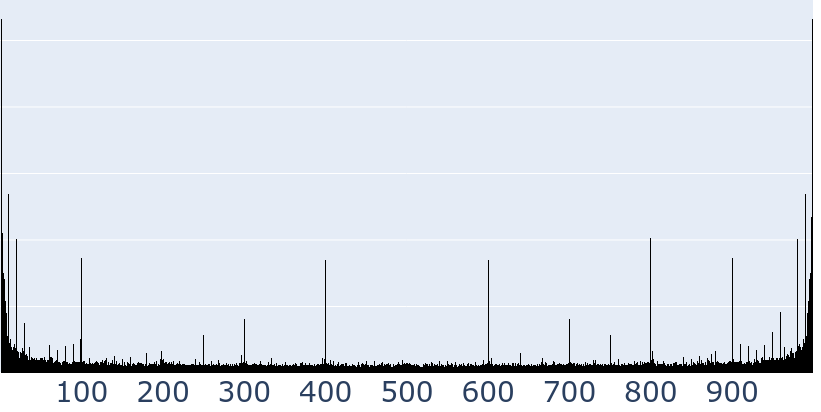

In [6]:
generate_fft_plots()

100%|█████████████████████████████████████████████| 8/8 [00:02<00:00,  3.52it/s]


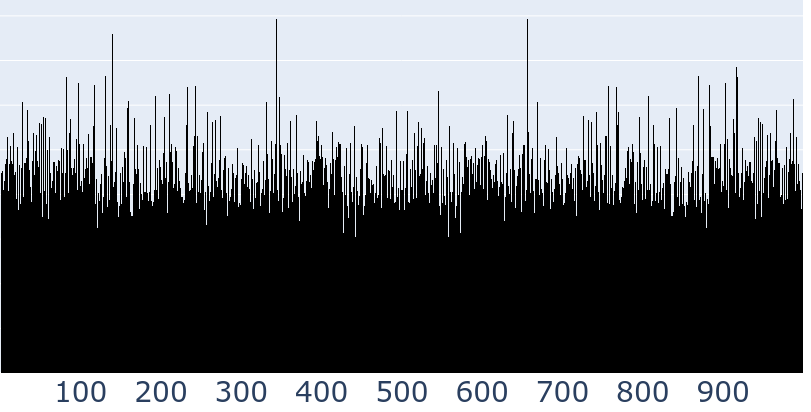

In [7]:

models_baseline: dict[str, ModelInfo] = {}
for nick, ckpt_name, arange, display_name in tqdm.tqdm(names_ranges):
    cache_filename = cache_dir / (ckpt_name.replace("/", "__") + ".baseline.safetensors")
    models_baseline[nick] = load_model("pretrained", ckpt_name, torch.arange(arange), shuffle=False, cache_file=cache_filename, display_name=display_name)

def generate_fft_plots_baseline():

    img_dir = pathlib.Path("fig_embs_fft")
    img_dir.mkdir(exist_ok=True)
    for i, (nick, model) in enumerate(models_baseline.items()):
        if model.tag != "pretrained":
            continue
        
        emb_pca, variances = pca(model.embs, 128)
        emb_fft = fourier(emb_pca)

        fig = plotly.express.bar(
            emb_fft.abs().max(dim=1).values.cpu().detach(),
            color_discrete_sequence=["black"]
        ).update_xaxes(
            #title="Frequency",
            title=None,
            ticktext=[model.arange.min(), model.arange.max()],
            dtick=100,
            tickfont=dict(size=28),
        ).update_yaxes(
            #title=model.display_name,
            title=None,
            title_font=dict(size=32),
            tickfont=dict(size=28),
            showticklabels=False,
        ).update_layout(
            showlegend=False,
            width=1200,
            height=400,
            margin=dict(l=0, r=8, t=0, b=0),
            bargap=0,
        ).update_traces(
            marker_line_width=0
        )
        fig.write_image(img_dir / f"embs_{nick}_pca_fft.baseline.png", format="png", scale=1)
        if i == 0:
            fig.show()

generate_fft_plots_baseline()

In [8]:
import pandas as pd
import seaborn as sns
from scipy.stats import kendalltau
import tqdm.auto
import itertools
import functools

@functools.cache
def to_freqs(model_name):
    emb_pca, variances = pca(models[modelA].embs, 128)
    emb_fft = fourier(emb_pca)
    freqs = emb_fft.abs().max(dim=1).values
    return freqs
    
records = []
model_names = [
    modelname
    for modelname in models 
    if not (modelname.startswith('sgn_') or modelname.startswith('shuffled_'))
]
for modelA, modelB in tqdm.auto.tqdm(list(itertools.combinations(model_names, 2))):
    freqs_A = to_freqs(modelA) 
    freqs_B = to_freqs(modelB) 
    tau, pval = kendalltau(freqs_A, freqs_B)
    records.append({'modelA': modelA, 'modelB': modelB, 'tau': tau, 'pval': pval})
    tau, pval = kendalltau(freqs_B, freqs_A)
    records.append({'modelA': modelB, 'modelB': modelA, 'tau': tau, 'pval': pval})

tau_df = pd.DataFrame.from_records(records)
tau_df

  0%|          | 0/28 [00:00<?, ?it/s]

,modelA,modelB,tau,pval
0,olmo1b,olmo7b,0.621564,5.089891e-190
1,olmo7b,olmo1b,0.621564,5.089891e-190
2,olmo1b,olmo13b,0.631039,8.575202e-196
3,olmo13b,olmo1b,0.631039,8.575202e-196
4,olmo1b,llama1b,0.626213,7.666465e-193
5,llama1b,olmo1b,0.626213,7.666465e-193
6,olmo1b,llama3b,0.620281,3.030609e-189
7,llama3b,olmo1b,0.620281,3.030609e-189
8,olmo1b,llama8b,0.627079,2.273950e-193
9,llama8b,olmo1b,0.627079,2.273950e-193


<Axes: xlabel='modelB', ylabel='modelA'>

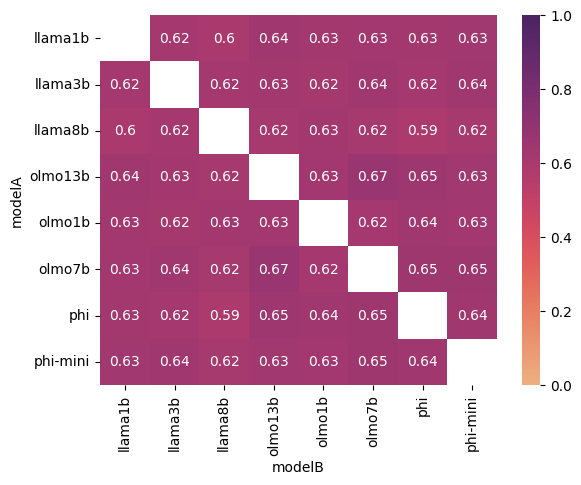

In [9]:
sns.heatmap(tau_df.pivot(columns='modelB', values='tau', index='modelA'), annot=True, vmin=0, vmax=1, cmap='flare')

In [10]:
import pandas as pd
import seaborn as sns
from scipy.stats import kendalltau
import tqdm.auto
import itertools
import functools

@functools.cache
def to_freqs_baseline(model_name):
    emb_pca, variances = pca(models_baseline[modelA].embs, 128)
    emb_fft = fourier(emb_pca)
    freqs = emb_fft.abs().max(dim=1).values
    return freqs
    
records = []
model_names = [
    modelname
    for modelname in models 
    if not (modelname.startswith('sgn_') or modelname.startswith('shuffled_'))
]
for modelA, modelB in tqdm.auto.tqdm(list(itertools.combinations(model_names, 2))):
    freqs_A = to_freqs_baseline(modelA) 
    freqs_B = to_freqs_baseline(modelB) 
    tau, pval = kendalltau(freqs_A, freqs_B)
    records.append({'modelA': modelA, 'modelB': modelB, 'tau': tau, 'pval': pval})
    tau, pval = kendalltau(freqs_B, freqs_A)
    records.append({'modelA': modelB, 'modelB': modelA, 'tau': tau, 'pval': pval})

tau_baseline_df = pd.DataFrame.from_records(records)
tau_baseline_df

  0%|          | 0/28 [00:00<?, ?it/s]

,modelA,modelB,tau,pval
0,olmo1b,olmo7b,0.666681,2.731434e-218
1,olmo7b,olmo1b,0.666681,2.731434e-218
2,olmo1b,olmo13b,0.661796,3.897964e-215
3,olmo13b,olmo1b,0.661796,3.897964e-215
4,olmo1b,llama1b,0.649355,3.350538e-207
5,llama1b,olmo1b,0.649355,3.350538e-207
6,olmo1b,llama3b,0.656017,1.974640e-211
7,llama3b,olmo1b,0.656017,1.974640e-211
8,olmo1b,llama8b,0.697003,2.105521e-238
9,llama8b,olmo1b,0.697003,2.105521e-238


<Axes: xlabel='modelB', ylabel='modelA'>

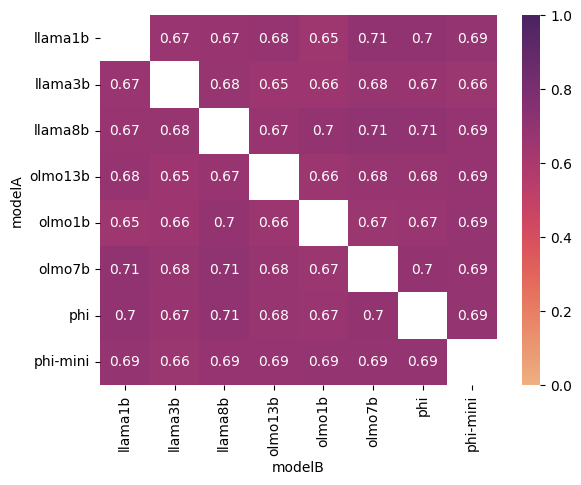

In [11]:
sns.heatmap(tau_baseline_df.pivot(columns='modelB', values='tau', index='modelA'), annot=True, vmin=0, vmax=1, cmap='flare')

  0%|          | 0/998 [00:00<?, ?it/s]

[(0.0, 1.0)]

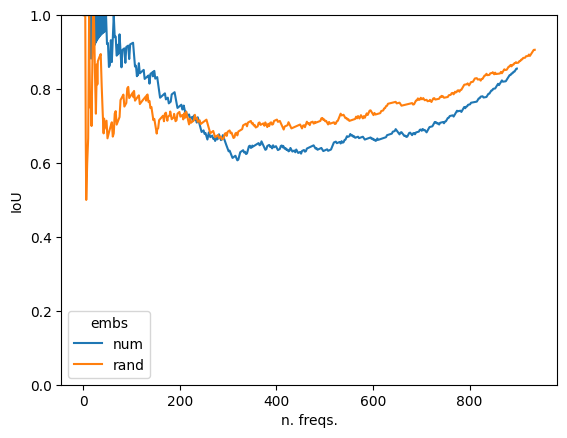

In [135]:
model_names = [
    modelname
    for modelname in models 
    if not (modelname.startswith('sgn_') or modelname.startswith('shuffled_'))
]


records = []
for nf in tqdm.auto.trange(1, 999): 
    def top_freqs(freqs):
        return set(torch.topk(freqs, nf).indices.tolist())
    def prop_accounted(freqs):
        return (torch.topk(freqs, nf).values.sum() / freqs.sum()).item()
    min_iou = float('inf')
    max_iou = -float('inf')
    for modelA, modelB in itertools.combinations(model_names, 2):
        freqs_A = top_freqs(to_freqs(modelA))
        freqs_B = top_freqs(to_freqs(modelB))
        iou = len(freqs_A & freqs_B) / len(freqs_A | freqs_B) 
        min_iou = min(iou, min_iou)
        max_iou = max(iou, max_iou)
    all_accounted =  all(prop_accounted(to_freqs(model)) > 0.95 for model in model_names)
    records.append({'n. freqs.': nf, 'IoU': min_iou, 'embs': 'num', 'extremum': 'min', 'all_accounted': all_accounted})
    records.append({'n. freqs.': nf, 'IoU': max_iou, 'embs': 'num', 'extremum': 'max', 'all_accounted': all_accounted})
    min_iou = float('inf')
    max_iou = -float('inf')
    for modelA, modelB in itertools.combinations(model_names, 2):
        freqs_A = top_freqs(to_freqs_baseline(modelA))
        freqs_B = top_freqs(to_freqs_baseline(modelB))
        iou = len(freqs_A & freqs_B) / len(freqs_A | freqs_B) 
        min_iou = min(iou, min_iou)
        max_iou = max(iou, max_iou)
    all_accounted =  all(prop_accounted(to_freqs_baseline(model)) > 0.95 for model in model_names)
    records.append({'n. freqs.': nf, 'IoU': min_iou, 'embs': 'rand', 'extremum': 'min', 'all_accounted': all_accounted})
    records.append({'n. freqs.': nf, 'IoU': max_iou, 'embs': 'rand', 'extremum': 'max', 'all_accounted': all_accounted})

agg_data = pd.DataFrame.from_records(records)

g = sns.lineplot(data=agg_data[(agg_data.extremum == 'min') & ~agg_data.all_accounted], x='n. freqs.', y='IoU', hue='embs')
g.set(ylim=(0,1))

In [118]:
records = []
for nf in tqdm.auto.trange(1, 999): 
    def top_freqs(freqs):
        return set(torch.topk(freqs, nf).indices.tolist())
    for modelA, modelB in itertools.combinations(model_names, 2):
        freqs_A = top_freqs(to_freqs(modelA))
        freqs_B = top_freqs(to_freqs(modelB))
        iou = len(freqs_A & freqs_B) / len(freqs_A | freqs_B) 
        records.append({'n. freqs.': nf, 'IoU': iou, 'embs': 'num', 'modelA': modelA, 'modelB': modelB})
        #records.append({'n. freqs.': nf, 'IoU': iou, 'embs': 'num', 'modelA': modelB, 'modelB': modelA})
    min_iou = float('inf')
    max_iou = -float('inf')
    for modelA, modelB in itertools.combinations(model_names, 2):
        freqs_A = top_freqs(to_freqs_baseline(modelA))
        freqs_B = top_freqs(to_freqs_baseline(modelB))
        iou = len(freqs_A & freqs_B) / len(freqs_A | freqs_B) 
        records.append({'n. freqs.': nf, 'IoU': iou, 'embs': 'rand', 'modelA': modelA, 'modelB': modelB})
        #records.append({'n. freqs.': nf, 'IoU': iou, 'embs': 'rand', 'modelA': modelB, 'modelB': modelA})
full_agg_data = pd.DataFrame.from_records(records)
full_agg_data

  0%|          | 0/998 [00:00<?, ?it/s]

,n. freqs.,IoU,embs,modelA,modelB
0,1,1.000000,num,olmo1b,olmo7b
1,1,1.000000,num,olmo1b,olmo13b
2,1,1.000000,num,olmo1b,llama1b
3,1,1.000000,num,olmo1b,llama3b
4,1,1.000000,num,olmo1b,llama8b
...,...,...,...,...,...
55883,998,0.997998,rand,llama3b,phi
55884,998,0.997998,rand,llama3b,phi-mini
55885,998,0.997998,rand,llama8b,phi
55886,998,1.000000,rand,llama8b,phi-mini


In [127]:
gap_data = (full_agg_data[full_agg_data['embs'] == 'num'].groupby('n. freqs.').IoU.min() - full_agg_data[full_agg_data['embs'] == 'rand'].groupby('n. freqs.').IoU.max()).reset_index()
gap_data[gap_data.IoU == gap_data.IoU.max()]

,n. freqs.,IoU
62,63,0.119403


[(0.0, 1.0)]

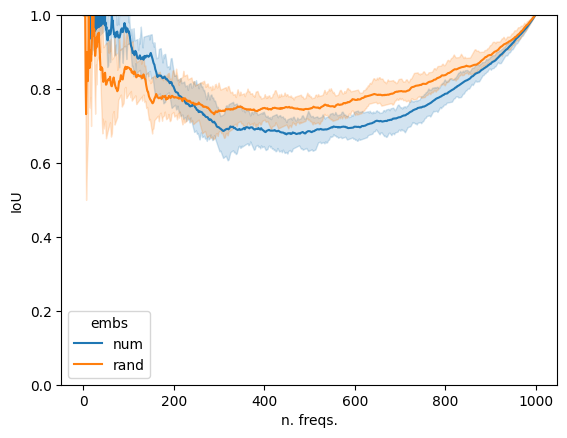

In [119]:
g = sns.lineplot(data=full_agg_data, x='n. freqs.', y='IoU', hue='embs', errorbar=lambda obs: (obs.min(), obs.max()))
g.set(ylim=(0,1))

In [105]:
N_FEATS = 63
def top_freqs(freqs):
    return set(torch.topk(freqs, N_FEATS).indices.tolist())


  0%|          | 0/28 [00:00<?, ?it/s]

<Axes: xlabel='modelB', ylabel='modelA'>

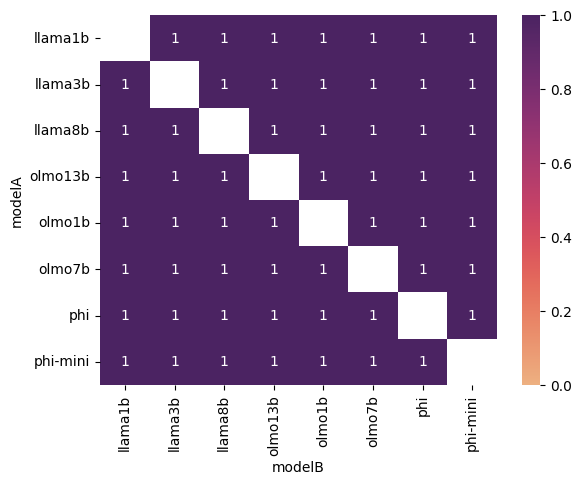

In [106]:
records = []
model_names = [
    modelname
    for modelname in models 
    if not (modelname.startswith('sgn_') or modelname.startswith('shuffled_'))
]
for modelA, modelB in tqdm.auto.tqdm(list(itertools.combinations(model_names, 2))):
    freqs_A = top_freqs(to_freqs(modelA))
    freqs_B = top_freqs(to_freqs(modelB))
    iou = len(freqs_A & freqs_B) / len(freqs_A | freqs_B) 
    records.append({'modelA': modelA, 'modelB': modelB, 'iou': iou})
    records.append({'modelA': modelB, 'modelB': modelA, 'iou': iou})
    
iou_df = pd.DataFrame.from_records(records)
sns.heatmap(
    iou_df.pivot(columns='modelB', values='iou', index='modelA'), 
    annot=True, vmin=0, vmax=1, cmap='flare'
)

  0%|          | 0/28 [00:00<?, ?it/s]

<Axes: xlabel='modelB', ylabel='modelA'>

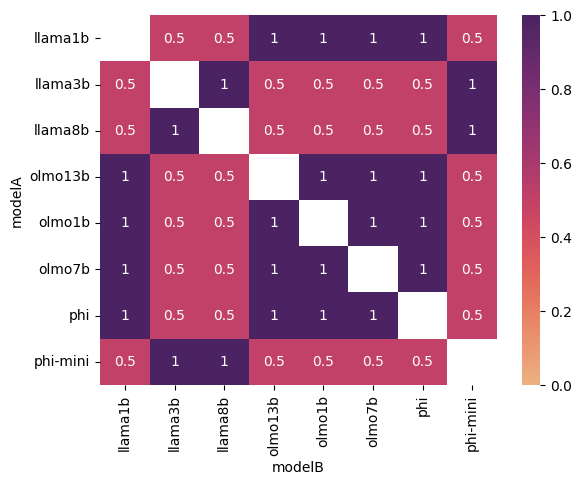

In [107]:
   
records = []
model_names = [
    modelname
    for modelname in models 
    if not (modelname.startswith('sgn_') or modelname.startswith('shuffled_'))
]
for modelA, modelB in tqdm.auto.tqdm(list(itertools.combinations(model_names, 2))):
    freqs_A = top_freqs(to_freqs_baseline(modelA))
    freqs_B = top_freqs(to_freqs_baseline(modelB))
    iou = len(freqs_A & freqs_B) / len(freqs_A | freqs_B) 
    records.append({'modelA': modelA, 'modelB': modelB, 'iou': iou})
    records.append({'modelA': modelB, 'modelB': modelA, 'iou': iou})
    
iou_baseline_df = pd.DataFrame.from_records(records)
sns.heatmap(
    iou_baseline_df.pivot(columns='modelB', values='iou', index='modelA'), 
    annot=True, vmin=0, vmax=1, cmap='flare'
)